In [54]:
import xmltodict
import requests
import pandas as pd
import time
import math

# 1. API 설정
api_key = "663c9e65449b13834dbba27c3cd63d6449181fee65c69ff348dc4c41fc959e42"
url = "http://apis.data.go.kr/B552584/EvCharger/getChargerInfo"

# 2. 먼저 1페이지 호출해서 totalCount 확인
params = {
    'serviceKey': api_key,
    'numOfRows': '10',
    'pageNo': '1'
}

response = requests.get(url, params=params)
dict_data = xmltodict.parse(response.content)

# totalCount는 body 안에 있음
total_count = int(dict_data['response']['header']['totalCount'])
print(f'전국 총 충전기 개수: {total_count}')

# 3. 페이지 수 계산
num_of_rows = 5000
total_pages = math.ceil(total_count / num_of_rows)
print(f'총 호출할 페이지 수: {total_pages}페이지 (1페이지 당 {num_of_rows}개씩)')

# 4. 전체 데이터 수집
all_items = []

for page in range(1, total_pages + 1):
    print(f'[{page}/{total_pages}] 페이지 수집 중...')

    params = {
        'serviceKey': api_key,
        'numOfRows': str(num_of_rows),
        'pageNo': str(page)
    }

    try:
        res = requests.get(url, params=params)
        data = xmltodict.parse(res.content)

        items = data['response']['body'].get('items', {}).get('item', [])

        if isinstance(items, dict):
            all_items.append(items)
        else:
            all_items.extend(items)

    except Exception as e:
        print(f'오류 발생 ({page}페이지): {e}')

    time.sleep(1)

print('모든 데이터 수집 완료!!')

df_all = pd.DataFrame(all_items)

print(f'최종 데이터 크기 : {df_all.shape}')

df_all.to_csv('전국_data.csv', index=False, encoding='utf-8-sig')
print('전국_data.csv 파일로 저장됨.')

전국 총 충전기 개수: 490770
총 호출할 페이지 수: 99페이지 (1페이지 당 5000개씩)
[1/99] 페이지 수집 중...
[2/99] 페이지 수집 중...
[3/99] 페이지 수집 중...
[4/99] 페이지 수집 중...
[5/99] 페이지 수집 중...
[6/99] 페이지 수집 중...
[7/99] 페이지 수집 중...
[8/99] 페이지 수집 중...
[9/99] 페이지 수집 중...
[10/99] 페이지 수집 중...
[11/99] 페이지 수집 중...
[12/99] 페이지 수집 중...
[13/99] 페이지 수집 중...
[14/99] 페이지 수집 중...
[15/99] 페이지 수집 중...
[16/99] 페이지 수집 중...
[17/99] 페이지 수집 중...
[18/99] 페이지 수집 중...
[19/99] 페이지 수집 중...
[20/99] 페이지 수집 중...
[21/99] 페이지 수집 중...
[22/99] 페이지 수집 중...
[23/99] 페이지 수집 중...
[24/99] 페이지 수집 중...
[25/99] 페이지 수집 중...
[26/99] 페이지 수집 중...
[27/99] 페이지 수집 중...
[28/99] 페이지 수집 중...
[29/99] 페이지 수집 중...
[30/99] 페이지 수집 중...
[31/99] 페이지 수집 중...
[32/99] 페이지 수집 중...
[33/99] 페이지 수집 중...
[34/99] 페이지 수집 중...
[35/99] 페이지 수집 중...
[36/99] 페이지 수집 중...
[37/99] 페이지 수집 중...
[38/99] 페이지 수집 중...
[39/99] 페이지 수집 중...
[40/99] 페이지 수집 중...
[41/99] 페이지 수집 중...
[42/99] 페이지 수집 중...
[43/99] 페이지 수집 중...
[44/99] 페이지 수집 중...
[45/99] 페이지 수집 중...
[46/99] 페이지 수집 중...
[47/99] 페이지 수집 중...
[48/99] 페이지 수집

In [101]:
df_all = pd.read_csv('전국_data.csv', encoding='utf-8-sig', low_memory=False)
df_all.shape

(490772, 37)

In [102]:
df = df_all[['statNm', 'chgerType', 'addr', 'useTime', 'year', 'stat' , 'parkingFree','kind']]
df

,statNm,chgerType,addr,useTime,year,stat,parkingFree,kind
0,낙성대동주민센터,6,서울특별시 관악구 낙성대로4가길 5,24시간 이용가능,2017,2,Y,G0
1,서울추모공원,6,서울특별시 서초구 양재대로12길 74,24시간 이용가능,2017,2,N,A0
2,롯데마트 송파점,6,서울특별시 송파구 중대로 80,24시간 이용가능,2017,2,N,E0
3,현대자동차 수색대리점,6,서울특별시 은평구 수색로 342-1,24시간 이용가능,2017,2,N,F0
4,태화빌딩,6,서울특별시 종로구 인사동5길 29,24시간 이용가능,2017,2,N,H0
...,...,...,...,...,...,...,...,...
490767,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,9,Y,B0
490768,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,9,Y,B0
490769,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,9,Y,B0
490770,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,9,Y,B0


In [103]:
df = df.rename(columns={
    'statNm': '충전소명',
    'chgerType': '충전기타입',
    'addr': '주소',
    'useTime': '이용가능시간',
    'year' : '제작년도',
    'stat' : '충전기상태',
    'parkingFree' : '무료주차',
    'kind' : '시설유형'
})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490772 entries, 0 to 490771
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   충전소명    490772 non-null  object
 1   충전기타입   490772 non-null  int64 
 2   주소      490772 non-null  object
 3   이용가능시간  485855 non-null  object
 4   제작년도    490772 non-null  int64 
 5   충전기상태   490772 non-null  int64 
 6   무료주차    490691 non-null  object
 7   시설유형    490658 non-null  object
dtypes: int64(3), object(5)
memory usage: 30.0+ MB


In [105]:
df['충전기타입'].unique()

array([ 6,  4, 11,  8,  2,  7,  5, 10,  1,  3])

In [106]:
# 4. 데이터 중복 제거 (동일한 충전소에 충전기가 여러 대 있는 경우, 충전소 단위 분석을 위해 중복 제거)

# ** 특성공학
# 1. 주소 데이터에서 '시/도' 파생 변수 생성
# # 예: "서울특별시 강남구 학동로..." -> 띄어쓰기 기준으로 나누어 첫 번째 요소인 "서울특별시" 추출
df['시/도'] = df['주소'].str.split().str[0]
df
# # 이름 통일화 (예: '서울시'와 '서울특별시'가 혼재되어 있다면 하나로 통일)
# # 여기서는 시/도 이름의 첫 두 글자만 따서 '서울', '부산', '제주' 등으로 통일
df['시/도'] = df['시/도'].str[:2]
df
# 2. 충전기 타입 범주화
# # API 코드값(01, 03 등)을 사람이 이해하기 쉬운 텍스트로 변환 (API 문서 기준) : 코드가 01 이면 완속, 03이면 급속, 06이면 초급속, 나머지는 기타
df['충전기상태'] = df['충전기상태'].map({
    1: '통신이상',
    2: '사용가능',
    3: '충전중',
    4: '운영중지',
    5: '점검중',
    9: '상태미확인' 
})
df


df['충전기타입기능'] = df['충전기타입'].map({
    1: '완속',
    2: '완속',
    3: '급속',
    4: '급속',
    5: '급속',
    6: '초급속',
    7: '초급속',
    8: '초급속',
    10: '초급속',
    11: '초급속'
}).fillna('기타')
df
# 3. 24시간 이용 가능 여부 파생 변수 생성
# # 이용시간 문자열에 '24시간'이 포함되어 있는지 여부를 boolean(True/False)으로 변환
df['24시간가능'] = df['이용가능시간'].str[:4] == '24시간'
df

# ** 시각화
# 시각화 1: 지역(시도)별 전기차 충전소 개수 비교 (Bar Chart)

# 시각화 2: 충전기 타입(완속/급속 등) 비율 (Pie Chart)

# 시각화 3: 지역별 24시간 개방 충전소 비율 (Stacked Bar Chart 또는 Countplot hue)

# ** 도출 인사이트

,충전소명,충전기타입,주소,이용가능시간,제작년도,충전기상태,무료주차,시설유형,시/도,충전기타입기능,24시간가능
0,낙성대동주민센터,6,서울특별시 관악구 낙성대로4가길 5,24시간 이용가능,2017,사용가능,Y,G0,서울,초급속,True
1,서울추모공원,6,서울특별시 서초구 양재대로12길 74,24시간 이용가능,2017,사용가능,N,A0,서울,초급속,True
2,롯데마트 송파점,6,서울특별시 송파구 중대로 80,24시간 이용가능,2017,사용가능,N,E0,서울,초급속,True
3,현대자동차 수색대리점,6,서울특별시 은평구 수색로 342-1,24시간 이용가능,2017,사용가능,N,F0,서울,초급속,True
4,태화빌딩,6,서울특별시 종로구 인사동5길 29,24시간 이용가능,2017,사용가능,N,H0,서울,초급속,True
...,...,...,...,...,...,...,...,...,...,...,...
490767,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,상태미확인,Y,B0,인천,급속,True
490768,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,상태미확인,Y,B0,인천,급속,True
490769,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,상태미확인,Y,B0,인천,급속,True
490770,인천교통공사01,4,인천광역시 서구 파랑로 105,24시간 이용가능,2024,상태미확인,Y,B0,인천,급속,True


In [107]:
지역별충전기갯수 = df.groupby('시/도')['충전소명'].count()
지역별충전기갯수

시/도
강서        21
강원     16483
거제         2
건영        21
경기    145175
경남      1427
경북       979
경산         6
경상     47789
광주     14497
괴산         7
다정         2
대구     23098
대전     14219
부산     30724
서울     71740
세종      6177
울산     10145
유성         1
인천     30522
전남       766
전라     14851
전북     16544
전주         4
제주      8415
진천        13
청주        59
충남      1688
충북       787
충청     34610
Name: 충전소명, dtype: int64

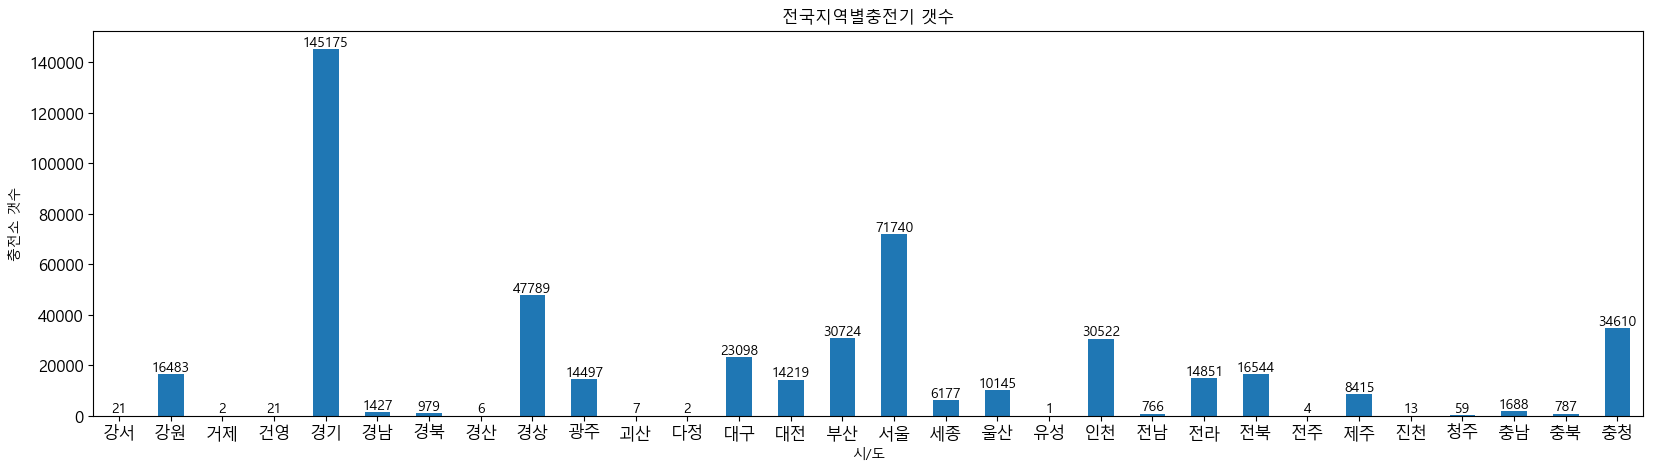

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


지역별충전기갯수.plot(kind='bar', figsize=(20,5), fontsize=12)
plt.title('전국지역별충전기 갯수')
plt.ylabel('충전소 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [109]:
년도별충전소갯수 = df.groupby('제작년도')['충전소명'].count()
년도별충전소갯수

제작년도
2014         1
2015         7
2016       197
2017      7370
2018     10296
2019     10921
2020     11019
2021     28361
2022     95737
2023    114153
2024    108223
2025     87229
2026     17257
2028         1
Name: 충전소명, dtype: int64

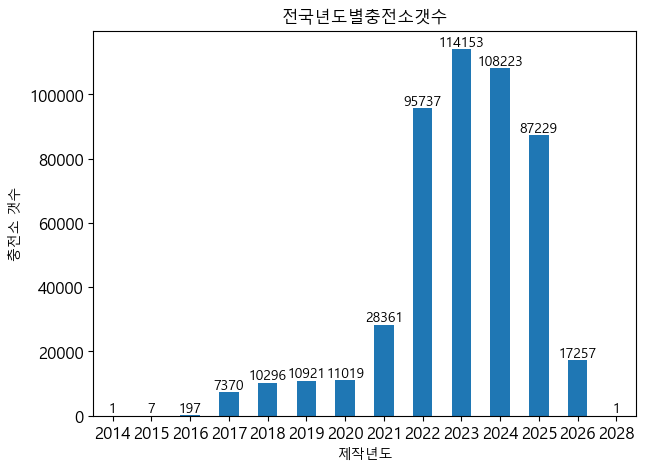

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 폰트 설정 (Windows: 'Malgun Gothic', Mac: 'AppleGothic')
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False


년도별충전소갯수.plot(kind='bar', figsize=(7,5), fontsize=12)
plt.title('전국년도별충전소갯수')
plt.ylabel('충전소 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [111]:
충전기타입비율 = df['충전기타입기능'].value_counts()

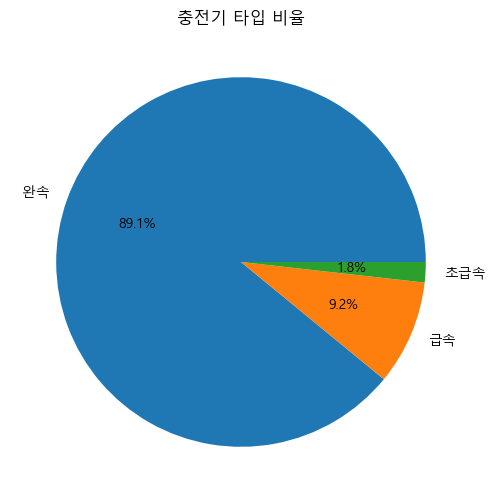

In [112]:
충전기타입비율.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title('충전기 타입 비율')
plt.ylabel('')

plt.show()

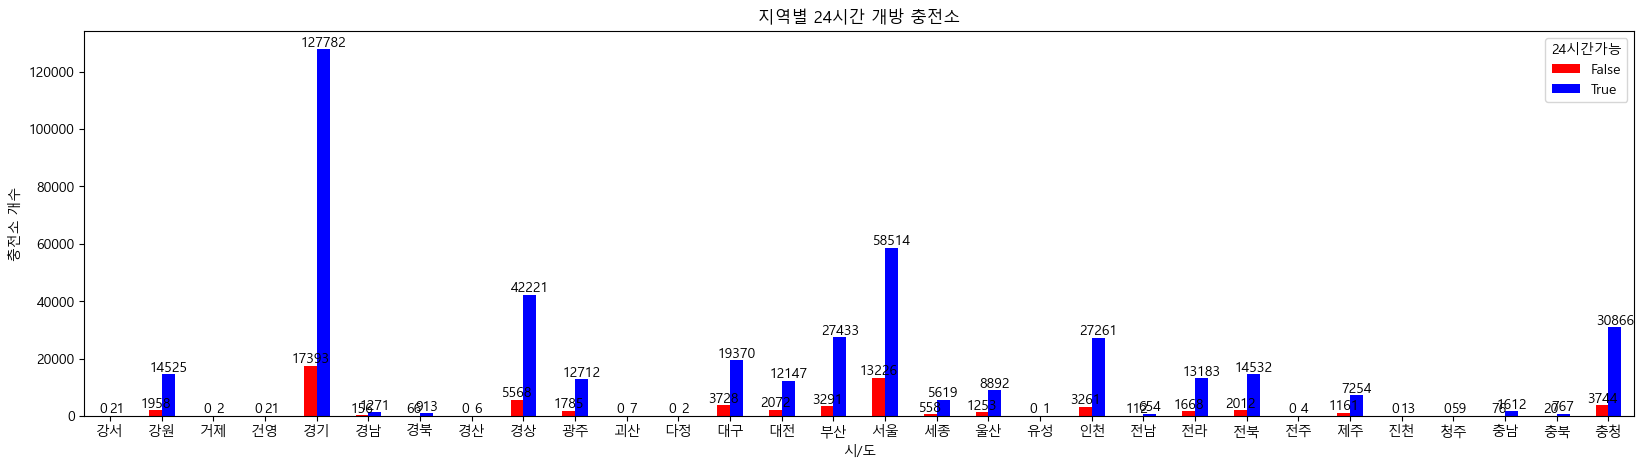

In [113]:
지역24 = df.groupby(['시/도','24시간가능']).size().unstack()

지역24.plot(kind='bar', color=['red','blue'], figsize=(20,5))

plt.title('지역별 24시간 개방 충전소')
plt.ylabel('충전소 개수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()

In [114]:
df[df['제작년도'] == 2028]

,충전소명,충전기타입,주소,이용가능시간,제작년도,충전기상태,무료주차,시설유형,시/도,충전기타입기능,24시간가능
487950,대구공작한양아파트,2,대구광역시 북구 구암로21길 38,24시간 이용가능,2028,사용가능,Y,H0,대구,완속,True


In [115]:
충전기상태별현황 = df.groupby('충전기상태')['충전소명'].count().sort_values(ascending=False)
충전기상태별현황

충전기상태
사용가능     406346
충전중       53322
상태미확인     18735
통신이상      10139
점검중        1646
운영중지        584
Name: 충전소명, dtype: int64

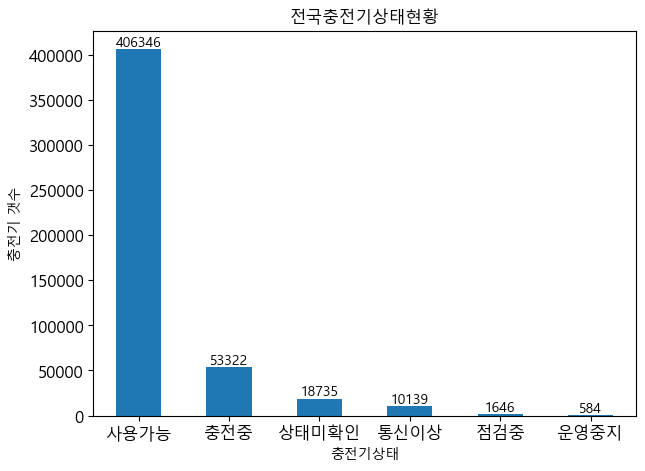

In [117]:
충전기상태별현황.plot(kind='bar', figsize=(7,5), fontsize=12)
plt.title('전국충전기상태현황')
plt.ylabel('충전기 갯수')
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f')

plt.show()